# nb05 — сколько живёт коинтеграция двух активов?

Это вопрос про **срок годности связи**, и от ответа зависит вся карта окон:
окно формации не может быть длиннее, чем живёт связь, а торговое окно должно
укладываться внутрь остатка её жизни.

**На каком TF мы работаем (для ясности):** панель часовая, β/mean/σ считаются на
часовых лог-ценах, `z` пересчитывается каждый час, вход/выход по закрытию часа.
Удержание при этом днями (медиана 113 ч в RAW, 52 ч в PROT). Здесь TF не меняем —
меряем срок жизни связи в календарных месяцах.

## Как корректно измерить «время жизни»

Наивно: «доля пар, у которых p<0.05 и через 3 месяца». Это плохая мера, потому что
доля коинтегрированных пар **сама по себе** гуляет от периода к периоду (в тихий
месяц её много, в трендовый мало). Тогда «выживаемость» перепутана с режимом рынка.

Поэтому меряем **lift** — во сколько раз пара, коинтегрированная в окне формации,
чаще проходит тест в будущем окне, чем случайная пара в **том же** будущем окне:

$$\text{lift}(k) = \frac{P(p<0.05 \text{ в окне } k \mid p<0.05 \text{ в формации})}{P(p<0.05 \text{ в окне } k)}$$

- `lift = 1` → память полностью потеряна, знание о прошлой коинтеграции бесполезно;
- `lift > 1` → связь ещё жива.

**Временем жизни** назовём горизонт, на котором избыток `lift − 1` падает вдвое.

Плюс два практических измерения, которые важнее самого теста:
- **дрейф β** — насколько уезжает коэффициент хеджа;
- **дрейф среднего спреда в единицах σ формации** — именно он убивает торговлю,
  потому что мы торгуем по *замороженному* mean/σ: если центр уехал на 2σ, то
  замороженный `z` показывает расхождение там, где его нет.

Всё внутри TRAIN (2024-01 … 2025-07), OOS заперт.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
lp = np.log(px[liq])
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
print(f"символов {len(liq)}, пар {len(PAIRS)}")

TR_LO, TR_HI = pd.Period("2024-01", "M"), pd.Period("2025-06", "M")


def win_slice(start_period, n_months):
    """Часовой срез окна из n_months календарных месяцев, начиная со start_period."""
    lo = pd.Timestamp(start_period.start_time, tz="UTC")
    hi = pd.Timestamp((start_period + n_months - 1).end_time, tz="UTC")
    if start_period < TR_LO or (start_period + n_months - 1) > TR_HI:
        return None
    return lp.loc[lo:hi]


_cache = {}


def window_stats(start_period, L):
    """p-value / beta / mean / sd спреда для ВСЕХ пар в окне (start, L). Кэшируется."""
    key = (str(start_period), L)
    if key in _cache:
        return _cache[key]
    w = win_slice(start_period, L)
    if w is None or len(w) < 200:
        _cache[key] = None
        return None
    res = {}
    for y, x in PAIRS:
        yv, xv = w[y].values, w[x].values
        p = coint(yv, xv, trend="c", maxlag=1, autolag=None)[1]
        beta = float(np.polyfit(xv, yv, 1)[0])
        s = yv - beta * xv
        res[(y, x)] = (p, beta, float(s.mean()), float(s.std()))
    _cache[key] = res
    return res


t0 = time.time()
_ = window_stats(TR_LO, 1)
print(f"одно окно (903 пары) считается {time.time()-t0:.1f}s")

символов 43, пар 903


одно окно (903 пары) считается 0.4s


## 1. Кривая выживания коинтеграции

Для каждой длины окна `L` (1, 2, 3, 6 месяцев) берём все возможные окна формации
внутри TRAIN. Пары с `p<0.05` в формации проверяем в **последующих непересекающихся**
окнах той же длины: горизонт `k` означает «через `k·L` месяцев».

Рядом считаем безусловную долю коинтегрированных пар в том же будущем окне —
это и есть контроль на режим рынка.

In [2]:
LS = [1, 2, 3, 6]
rows = []
t0 = time.time()
for L in LS:
    starts = [p for p in pd.period_range(TR_LO, TR_HI, freq="M")
              if (p + L - 1) <= TR_HI]
    for s in starts:
        f = window_stats(s, L)
        if f is None:
            continue
        sel = [k for k, v in f.items() if v[0] < 0.05]
        if len(sel) < 5:
            continue
        k = 1
        while True:
            s2 = s + k * L
            if (s2 + L - 1) > TR_HI:
                break
            g = window_stats(s2, L)
            if g is None:
                break
            cond = np.mean([g[pr][0] < 0.05 for pr in sel])
            base = np.mean([v[0] < 0.05 for v in g.values()])
            dbeta = np.median([abs(g[pr][1] - f[pr][1]) / max(abs(f[pr][1]), 1e-6) for pr in sel])
            dmean = np.median([abs(g[pr][2] - f[pr][2]) / f[pr][3] for pr in sel])
            dsd = np.median([g[pr][3] / f[pr][3] for pr in sel])
            rows.append({"L": L, "k": k, "мес_вперёд": k * L, "окно_формации": str(s),
                         "n_sel": len(sel), "усл_доля": cond, "базовая_доля": base,
                         "lift": cond / base if base > 0 else np.nan,
                         "дрейф_β_отн": dbeta, "дрейф_mean_в_σ": dmean, "σ_ratio": dsd})
            k += 1
S = pd.DataFrame(rows)
print(f"посчитано за {time.time()-t0:.0f}s, наблюдений (окно × горизонт): {len(S)}")

agg = (S.groupby(["L", "мес_вперёд"])
       .agg(окон=("окно_формации", "size"), пар=("n_sel", "mean"),
            усл_доля=("усл_доля", "mean"), базовая=("базовая_доля", "mean"),
            lift=("lift", "mean"), дрейф_β=("дрейф_β_отн", "mean"),
            дрейф_mean_σ=("дрейф_mean_в_σ", "mean"), σ_ratio=("σ_ratio", "mean"))
       .round(3))
print()
print("ВЫЖИВАНИЕ КОИНТЕГРАЦИИ (усреднено по окнам формации)")
print(agg.to_string())

посчитано за 36s, наблюдений (окно × горизонт): 260

ВЫЖИВАНИЕ КОИНТЕГРАЦИИ (усреднено по окнам формации)
              окон      пар  усл_доля  базовая   lift  дрейф_β  дрейф_mean_σ  σ_ratio
L мес_вперёд                                                                         
1 1             17  103.000     0.128    0.115  1.089    0.655        20.779    1.467
  2             16  104.938     0.112    0.116  0.963    0.755        23.439    1.509
  3             15  106.800     0.126    0.117  1.081    0.626        23.955    1.476
  4             14  103.214     0.124    0.117  1.107    0.726        26.540    1.469
  5             13   99.769     0.130    0.121  1.157    0.670        24.697    1.402
  6             12   99.667     0.112    0.125  0.854    0.715        27.614    1.669
  7             11   91.000     0.149    0.127  1.151    0.708        27.985    1.573
  8             10   91.400     0.168    0.127  1.308    0.667        26.550    1.450
  9              9   86.889     0.

### 1b. Контроль: `lift ≈ 1` — это «связь умерла» или «тест сам шум»?

`lift ≈ 1` на следующем окне допускает два совершенно разных объяснения:

- **связь действительно распадается** между окнами;
- **тест EG на таком окне настолько шумный**, что даже вечно-коинтегрированная пара
  проходит его через раз, и никакой памяти он показать не может в принципе.

Отличить можно так: разбить **одно и то же окно** на две подвыборки по **чётности
дня** и проверить, предсказывает ли `p<0.05` на чётных днях такой же результат на
нечётных. Подвыборки покрывают **тот же самый период**, поэтому «связь изменилась»
здесь исключено по построению — остаётся только шум теста.

- Если `lift_внутри` большой, а `lift_вперёд ≈ 1` → тест работает, связь правда живёт
  меньше окна.
- Если `lift_внутри` тоже ≈ 1 → тест на этом окне бесполезен, и все выводы про
  «время жизни» надо строить на другом критерии (скорость возврата, а не p-value).

(Прореживание по дням меняет автокорреляционную структуру, но коинтеграция при
прореживании сохраняется — тест остаётся применимым.)

In [3]:
def parity_pvalues(start_period, L):
    """p-value для всех пар на чётных и нечётных днях ОДНОГО окна."""
    w = win_slice(start_period, L)
    if w is None or len(w) < 400:
        return None
    odd = w[w.index.day % 2 == 1]
    even = w[w.index.day % 2 == 0]
    out = {}
    for y, x in PAIRS:
        po = coint(odd[y].values, odd[x].values, trend="c", maxlag=1, autolag=None)[1]
        pe = coint(even[y].values, even[x].values, trend="c", maxlag=1, autolag=None)[1]
        out[(y, x)] = (po, pe)
    return out


print("НАДЁЖНОСТЬ ТЕСТА: одно окно, разбитое по чётности дня")
print("(здесь связь измениться НЕ может — период тот же; остаётся только шум теста)\n")
rel_rows = []
for L in [1, 2, 3]:
    starts = [p for p in pd.period_range(TR_LO, TR_HI, freq="M") if (p + L - 1) <= TR_HI][:6]
    for s in starts:
        pv = parity_pvalues(s, L)
        if pv is None:
            continue
        sel = [k for k, v in pv.items() if v[0] < 0.05]
        if len(sel) < 5:
            continue
        cond = np.mean([pv[k][1] < 0.05 for k in sel])
        base = np.mean([v[1] < 0.05 for v in pv.values()])
        rel_rows.append({"L": L, "окно": str(s), "n_sel": len(sel),
                         "усл_доля": cond, "базовая": base,
                         "lift_внутри": cond / base if base > 0 else np.nan})
REL = pd.DataFrame(rel_rows)
relagg = REL.groupby("L").agg(окон=("окно", "size"), пар=("n_sel", "mean"),
                              усл_доля=("усл_доля", "mean"), базовая=("базовая", "mean"),
                              lift_внутри=("lift_внутри", "mean")).round(3)
print(relagg.to_string())
print()
print("для сравнения — lift на СЛЕДУЮЩЕЕ окно (из §1):")
for L in [1, 2, 3]:
    print(f"  L={L}: lift_внутри {relagg.loc[L, 'lift_внутри']:.2f}   "
          f"lift_вперёд {agg.loc[L].lift.iloc[0]:.2f}")
print()
if (relagg.lift_внутри > 2).all():
    print("ВЫВОД: тест внутри окна воспроизводится (lift >> 1), значит он информативен,")
    print("а падение lift до ~1 на следующем окне = связь РЕАЛЬНО не переживает окно.")
else:
    print("ВЫВОД: тест плохо воспроизводится даже внутри одного окна => p-value EG на")
    print("таком окне — в основном шум, и им нельзя мерить время жизни связи.")

НАДЁЖНОСТЬ ТЕСТА: одно окно, разбитое по чётности дня
(здесь связь измениться НЕ может — период тот же; остаётся только шум теста)



   окон     пар  усл_доля  базовая  lift_внутри
L                                              
1     6  51.500     0.442    0.068        7.463
2     6  87.833     0.661    0.106        7.865
3     6  90.333     0.703    0.097        8.679

для сравнения — lift на СЛЕДУЮЩЕЕ окно (из §1):
  L=1: lift_внутри 7.46   lift_вперёд 1.09
  L=2: lift_внутри 7.87   lift_вперёд 0.98
  L=3: lift_внутри 8.68   lift_вперёд 0.93

ВЫВОД: тест внутри окна воспроизводится (lift >> 1), значит он информативен,
а падение lift до ~1 на следующем окне = связь РЕАЛЬНО не переживает окно.


### 1c. Дрейф при ЗАМОРОЖЕННОЙ β — то, что реально видит торговля

В §1 дрейф центра считался неверно: средние сравнивались у спредов, построенных с
**разными** β (в каждом окне β переоценивается). Смена β сдвигает сам уровень
спреда на `Δβ·log(цена)`, а `log(цена)` — величина порядка единиц-десятков, поэтому
получались фантомные 20σ.

Правильно так, как это устроено в торговле: **β, mean и σ заморожены с окна
формации**, и мы смотрим, куда уезжает спред, посчитанный этой же β.

ДРЕЙФ ПРИ ЗАМОРОЖЕННОЙ β (так, как это видит торговля)
              окон  дрейф_центра_σ  σ_ratio  время_вне_2σ
L мес_вперёд                                             
1 1             17           2.440    2.151         0.557
  2             16           5.411    2.230         0.858
  3             15           8.002    2.022         0.944
  4             14           9.604    2.027         0.978
  5             13          11.510    1.949         0.986
  6             12          11.813    2.406         0.998
  7             11          13.841    2.190         0.999
  8             10          14.178    2.049         0.993
  9              9          14.271    2.217         1.000
  10             8          16.282    2.194         1.000
  11             7          17.914    1.866         1.000
  12             6          17.659    1.778         1.000
  13             5          21.974    2.184         1.000
  14             4          21.940    1.659         1.000
  15             

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb05_frozen_drift.png')

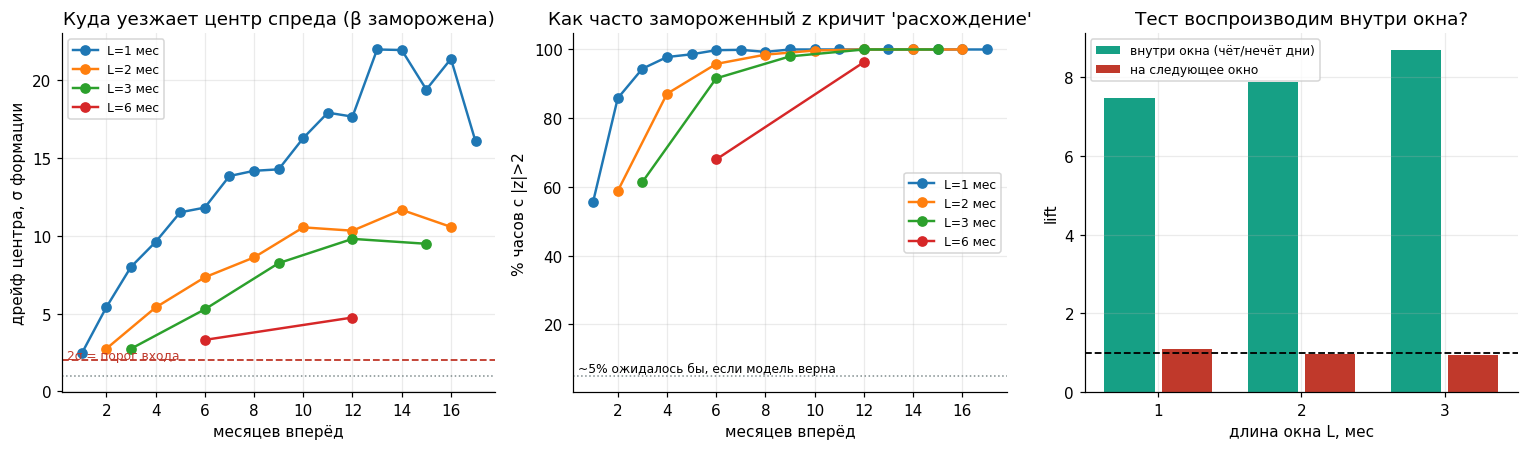

In [4]:
def frozen_drift(s_period, L, k, sel, f):
    """Дрейф спреда на горизонте k при ЗАМОРОЖЕННЫХ с формации beta/mean/sd."""
    w = win_slice(s_period + k * L, L)
    if w is None:
        return None
    dm, sr, tail = [], [], []
    for pr in sel:
        beta, mu, sd = f[pr][1], f[pr][2], f[pr][3]
        s_h = (w[pr[0]] - beta * w[pr[1]]).values
        dm.append(abs(s_h.mean() - mu) / sd)
        sr.append(s_h.std() / sd)
        z = (s_h - mu) / sd
        tail.append(float(np.mean(np.abs(z) > 2)))
    return (float(np.median(dm)), float(np.median(sr)), float(np.median(tail)))


rows2 = []
for L in LS:
    starts = [p for p in pd.period_range(TR_LO, TR_HI, freq="M") if (p + L - 1) <= TR_HI]
    for s in starts:
        f = window_stats(s, L)
        if f is None:
            continue
        sel = [kk for kk, v in f.items() if v[0] < 0.05]
        if len(sel) < 5:
            continue
        k = 1
        while (s + (k + 1) * L - 1) <= TR_HI:
            d = frozen_drift(s, L, k, sel, f)
            if d is None:
                break
            rows2.append({"L": L, "мес_вперёд": k * L, "дрейф_mean_σ": d[0],
                          "σ_ratio": d[1], "доля_времени_|z|>2": d[2]})
            k += 1
D = pd.DataFrame(rows2)
dagg = (D.groupby(["L", "мес_вперёд"])
        .agg(окон=("дрейф_mean_σ", "size"), дрейф_центра_σ=("дрейф_mean_σ", "mean"),
             σ_ratio=("σ_ratio", "mean"), время_вне_2σ=("доля_времени_|z|>2", "mean"))
        .round(3))
print("ДРЕЙФ ПРИ ЗАМОРОЖЕННОЙ β (так, как это видит торговля)")
print(dagg.to_string())
print()
print("как читать 'время_вне_2σ': доля часов горизонта, где замороженный |z| > 2.")
print("В окне формации по определению ~5%. Если стало 30-50% — центр уехал и")
print("сигнал 'расхождение' срабатывает постоянно, т.е. модель уже неверна.\n")
for L in LS:
    a = dagg.loc[L]
    ok = a[a.дрейф_центра_σ < 1.0]
    lim = ok.index.max() if len(ok) else 0
    print(f"  L={L} мес: дрейф центра < 1σ держится до {lim} мес вперёд; "
          f"на первом горизонте ({a.index[0]} мес) дрейф {a.дрейф_центра_σ.iloc[0]:.2f}σ, "
          f"вне 2σ {a.время_вне_2σ.iloc[0]*100:.0f}% времени")

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for L in LS:
    a = dagg.loc[L]
    ax[0].plot(a.index, a.дрейф_центра_σ, "o-", lw=1.6, label=f"L={L} мес")
ax[0].axhline(2, color="#c0392b", ls="--", lw=1.2)
ax[0].text(0.4, 2.1, "2σ = порог входа", fontsize=8, color="#c0392b")
ax[0].axhline(1, color="#7f8c8d", ls=":", lw=1)
ax[0].set_xlabel("месяцев вперёд"); ax[0].set_ylabel("дрейф центра, σ формации")
ax[0].set_title("Куда уезжает центр спреда (β заморожена)"); ax[0].legend(fontsize=8)

for L in LS:
    a = dagg.loc[L]
    ax[1].plot(a.index, a.время_вне_2σ*100, "o-", lw=1.6, label=f"L={L} мес")
ax[1].axhline(5, color="#7f8c8d", ls=":", lw=1)
ax[1].text(0.4, 6, "~5% ожидалось бы, если модель верна", fontsize=8)
ax[1].set_xlabel("месяцев вперёд"); ax[1].set_ylabel("% часов с |z|>2")
ax[1].set_title("Как часто замороженный z кричит 'расхождение'"); ax[1].legend(fontsize=8)

for L in [1, 2, 3]:
    ax[2].bar([L - 0.2], [relagg.loc[L, "lift_внутри"]], width=0.35, color="#16a085",
              label="внутри окна (чёт/нечёт дни)" if L == 1 else None)
    ax[2].bar([L + 0.2], [agg.loc[L].lift.iloc[0]], width=0.35, color="#c0392b",
              label="на следующее окно" if L == 1 else None)
ax[2].axhline(1, color="black", ls="--", lw=1.2)
ax[2].set_xticks([1, 2, 3]); ax[2].set_xlabel("длина окна L, мес")
ax[2].set_ylabel("lift"); ax[2].set_title("Тест воспроизводим внутри окна?")
ax[2].legend(fontsize=8)
show("nb05_frozen_drift")

In [5]:
print("ИНТЕРПРЕТАЦИЯ: сколько живёт связь")
print("lift=1 означает 'память потеряна полностью'. Смотрим, как быстро избыток")
print("lift-1 сходит к нулю.\n")
for L in LS:
    a = agg.loc[L]
    if not len(a):
        continue
    excess0 = a.lift.iloc[0] - 1
    print(f"L={L} мес (в окне формации lift по определению ~{1/a.базовая.iloc[0]:.1f}x):")
    for m, r in a.iterrows():
        mark = ""
        if excess0 > 0:
            frac = (r.lift - 1) / excess0
            mark = f"   избыток = {frac*100:5.1f}% от первого горизонта"
        print(f"   через {m:>2} мес: lift {r.lift:5.2f}  "
              f"(усл {r.усл_доля*100:4.1f}% против базовой {r.базовая*100:4.1f}%){mark}")
    print()

print("(замер дрейфа перенесён в §1c — там он считается при замороженной beta)")


ИНТЕРПРЕТАЦИЯ: сколько живёт связь
lift=1 означает 'память потеряна полностью'. Смотрим, как быстро избыток
lift-1 сходит к нулю.

L=1 мес (в окне формации lift по определению ~8.7x):
   через  1 мес: lift  1.09  (усл 12.8% против базовой 11.5%)   избыток = 100.0% от первого горизонта
   через  2 мес: lift  0.96  (усл 11.2% против базовой 11.6%)   избыток = -41.6% от первого горизонта
   через  3 мес: lift  1.08  (усл 12.6% против базовой 11.7%)   избыток =  91.0% от первого горизонта
   через  4 мес: lift  1.11  (усл 12.4% против базовой 11.7%)   избыток = 120.2% от первого горизонта
   через  5 мес: lift  1.16  (усл 13.0% против базовой 12.1%)   избыток = 176.4% от первого горизонта
   через  6 мес: lift  0.85  (усл 11.2% против базовой 12.5%)   избыток = -164.0% от первого горизонта
   через  7 мес: lift  1.15  (усл 14.9% против базовой 12.7%)   избыток = 169.7% от первого горизонта
   через  8 мес: lift  1.31  (усл 16.8% против базовой 12.7%)   избыток = 346.1% от первого горизонта

[saved] notebooks\statarb\_out\nb05_lifetime.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb05_lifetime.png')

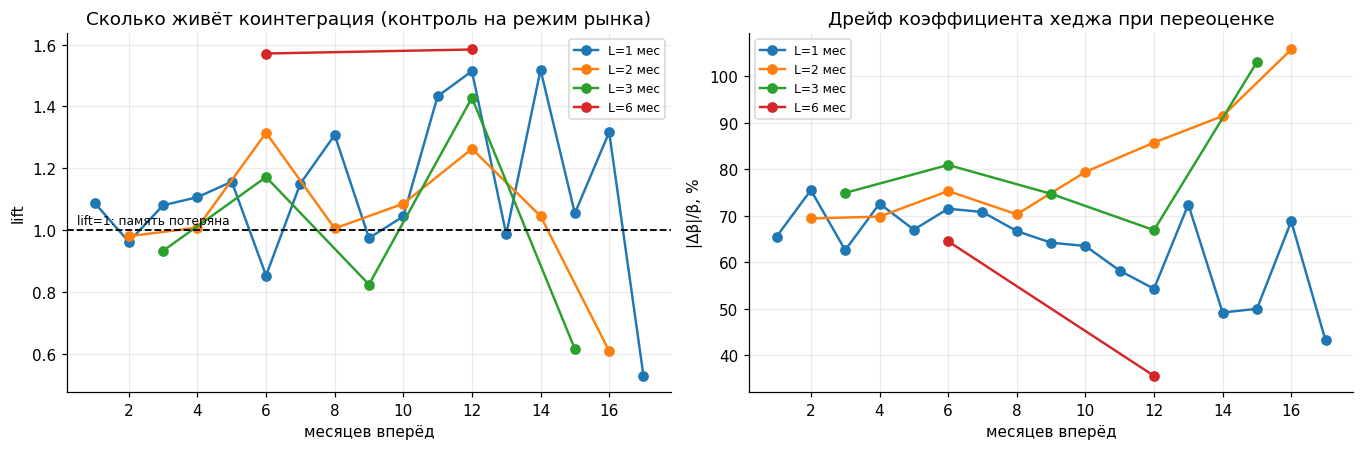

In [6]:
# Панель дрейфа центра ПЕРЕЕХАЛА в §1c: здесь она считалась при переоценённой
# beta и давала фантомные 20-35 sigma (смена beta сдвигает уровень спреда на
# delta_beta * log(цена)). Оставляем только то, что корректно на этих данных.
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
for L in LS:
    a = agg.loc[L]
    ax[0].plot(a.index, a.lift, "o-", lw=1.6, label=f"L={L} мес")
ax[0].axhline(1, color="black", lw=1.2, ls="--")
ax[0].text(0.5, 1.02, "lift=1: память потеряна", fontsize=8)
ax[0].set_xlabel("месяцев вперёд"); ax[0].set_ylabel("lift")
ax[0].set_title("Сколько живёт коинтеграция (контроль на режим рынка)")
ax[0].legend(fontsize=8)

for L in LS:
    a = agg.loc[L]
    ax[1].plot(a.index, a.дрейф_β*100, "o-", lw=1.6, label=f"L={L} мес")
ax[1].set_xlabel("месяцев вперёд"); ax[1].set_ylabel("|Δβ|/β, %")
ax[1].set_title("Дрейф коэффициента хеджа при переоценке")
ax[1].legend(fontsize=8)
show("nb05_lifetime")


## 2. Второй масштаб времени: half-life самого спреда

Есть два разных «времени» и их нельзя путать:

- **half-life спреда** — как быстро расхождение возвращается к среднему (часы-дни);
- **время жизни связи** — как долго вообще существует то среднее, к которому
  возвращаться (недели-месяцы).

Отношение второго к первому = **сколько сделок физически успевает произойти,
пока связь жива**. Если связь живёт 1 месяц, а half-life 10 дней, то внутри её
жизни укладывается всего 2-3 полных возврата — и любая ошибка отбора съедает всё.

In [7]:
def hl_bars(s):
    lag, d = s[:-1], np.diff(s)
    b = np.polyfit(lag, d, 1)[0]
    return np.nan if b >= 0 else float(-np.log(2) / np.log(1 + b))


rows = []
for L in LS:
    starts = [p for p in pd.period_range(TR_LO, TR_HI, freq="M") if (p + L - 1) <= TR_HI]
    hls = []
    for s in starts:
        f = window_stats(s, L)
        if f is None:
            continue
        w = win_slice(s, L)
        sel = [k for k, v in f.items() if v[0] < 0.05]
        for y, x in sel[:60]:
            beta = f[(y, x)][1]
            hls.append(hl_bars((w[y] - beta * w[x]).values))
    hls = np.array([h for h in hls if np.isfinite(h)])
    rows.append({"L, мес": L, "пар": len(hls),
                 "HL медиана, ч": round(float(np.median(hls))),
                 "HL медиана, дней": round(float(np.median(hls))/24, 1),
                 "HL q25, дней": round(float(np.percentile(hls, 25))/24, 1),
                 "HL q75, дней": round(float(np.percentile(hls, 75))/24, 1),
                 "HL / длина окна": round(float(np.median(hls)) / (L*730), 3)})
H = pd.DataFrame(rows)
print("HALF-LIFE СПРЕДА у отобранных пар (оценка на окне формации)")
print(H.to_string(index=False))
print("\nвнимание на последний столбец: HL как доля длины окна формации.")
print("Если HL сравним с длиной окна, оценка half-life ненадёжна (мало полных")
print("циклов возврата внутри окна) — классическое смещение короткого окна.")

HALF-LIFE СПРЕДА у отобранных пар (оценка на окне формации)
 L, мес  пар  HL медиана, ч  HL медиана, дней  HL q25, дней  HL q75, дней  HL / длина окна
      1 1074             19               0.8           0.7           1.0            0.027
      2 1016             39               1.6           1.4           2.0            0.027
      3  947             59               2.4           2.0           2.9            0.027
      6  751            117               4.9           3.9           5.8            0.027

внимание на последний столбец: HL как доля длины окна формации.
Если HL сравним с длиной окна, оценка half-life ненадёжна (мало полных
циклов возврата внутри окна) — классическое смещение короткого окна.


## 3. Карта окон: что из этого следует

Числа выше дают три ограничения, из которых и складывается карта свипа:

1. **Окно формации** должно быть достаточно длинным, чтобы β/mean/σ оценивались
   не по шуму (нужно много half-life внутри окна), но короче времени жизни связи.
2. **Торговое окно** должно быть коротким относительно дрейфа центра: торговать надо,
   пока дрейф центра ощутимо меньше порога входа 2σ.
3. **Переоценка** (refit) должна происходить чаще, чем связь успевает уехать.

Ниже — предложение сетки, посчитанное из измеренного дрейфа, а не выбранное на глаз.

In [8]:
print("ОГРАНИЧЕНИЕ 1: сколько half-life укладывается в окно формации")
print("(ориентир: для устойчивой оценки возврата нужно >= 10 HL внутри окна)\n")
for _, r in H.iterrows():
    L = r["L, мес"]
    n_hl = (L * 730) / r["HL медиана, ч"]
    print(f"  L={L} мес ({int(L*730):>4} ч): {n_hl:5.1f} half-life внутри окна")

print("\n!! ПОДОЗРИТЕЛЬНО: HL/длина_окна = 0.027 при ВСЕХ четырёх L.")
print("   Half-life отобранных пар растёт строго пропорционально окну:")
print("   19 ч (1 мес) -> 39 ч (2) -> 59 ч (3) -> 117 ч (6).")
print("   У настоящего OU-процесса HL — свойство пары и от длины окна зависеть не")
print("   должен. Две причины, обе неприятные:")
print("   (1) отбор: на длинном окне ADF мощнее и пропускает более медленные пары;")
print("   (2) при близком к случайному блужданию спреде AR(1)-оценка HL")
print("       масштабируется с длиной выборки — то есть мы мерим окно, а не процесс.")

print("\n\nОГРАНИЧЕНИЕ 2: дрейф центра при ЗАМОРОЖЕННОЙ beta (§1c)")
for L in LS:
    a = dagg.loc[L]
    print(f"  L={L} мес: на первом же горизонте ({a.index[0]} мес) центр уехал на "
          f"{a.дрейф_центра_σ.iloc[0]:.2f}σ, sigma выросла x{a.σ_ratio.iloc[0]:.2f}, "
          f"|z|>2 держится {a.время_вне_2σ.iloc[0]*100:.0f}% времени")
print("  ни при одной L дрейф центра не остаётся ниже 1σ даже на один шаг вперёд.")

print("\n\nОГРАНИЧЕНИЕ 3: память теста")
for L in [1, 2, 3]:
    print(f"  L={L} мес: lift внутри окна {relagg.loc[L,'lift_внутри']:.2f} "
          f"(тест воспроизводим) против lift вперёд {agg.loc[L].lift.iloc[0]:.2f} "
          f"(памяти нет)")

print("""

ЧТО ЭТО ЗНАЧИТ ДЛЯ КАРТЫ ОКОН

Замер отвечает на исходный вопрос жёстко: коинтеграция пары ЖИВЁТ МЕНЬШЕ ОДНОГО
окна на всех проверенных длинах (1-6 мес). Тест при этом рабочий — внутри того же
периода он воспроизводится с lift ~8. Значит проблема не в измерении, а в самой
связи: она не переносится вперёд.

Отсюда сетка "формация L x торговое окно T" в прежнем виде БЕССМЫСЛЕННА: свипировать
L от 1 до 6 месяцев нет смысла, потому что ни одна из этих длин не даёт памяти.
Осмысленных направлений три, и все они меняют не длину окна, а сам ОБЪЕКТ:

  A. КОРОТКИЕ окна (дни-недели, не месяцы). Единственная неисследованная часть
     шкалы. Проверять надо на 1-14 дней с торговлей на 1-3 дня. Ожидание: там
     живёт не коинтеграция, а краткосрочный реверс остатка.
  B. ROLLING вместо FROZEN. Дрейф центра 2.4σ за месяц убивает замороженную
     модель, но скользящая оценка mean/sigma переопределяет центр непрерывно.
     Это меняет саму постановку: торгуем не "возврат к историческому среднему",
     а "возврат к недавнему".
  C. Не искать стационарность перебором, а строить остаток от ФАКТОРОВ
     (рынок/сектор). Тогда веса берутся из ковариации и не обязаны быть
     стационарными - нейтральность задаётся конструкцией, а не тестом.
""")

ОГРАНИЧЕНИЕ 1: сколько half-life укладывается в окно формации
(ориентир: для устойчивой оценки возврата нужно >= 10 HL внутри окна)

  L=1.0 мес ( 730 ч):  38.4 half-life внутри окна
  L=2.0 мес (1460 ч):  37.4 half-life внутри окна
  L=3.0 мес (2190 ч):  37.1 half-life внутри окна
  L=6.0 мес (4380 ч):  37.4 half-life внутри окна

!! ПОДОЗРИТЕЛЬНО: HL/длина_окна = 0.027 при ВСЕХ четырёх L.
   Half-life отобранных пар растёт строго пропорционально окну:
   19 ч (1 мес) -> 39 ч (2) -> 59 ч (3) -> 117 ч (6).
   У настоящего OU-процесса HL — свойство пары и от длины окна зависеть не
   должен. Две причины, обе неприятные:
   (1) отбор: на длинном окне ADF мощнее и пропускает более медленные пары;
   (2) при близком к случайному блужданию спреде AR(1)-оценка HL
       масштабируется с длиной выборки — то есть мы мерим окно, а не процесс.


ОГРАНИЧЕНИЕ 2: дрейф центра при ЗАМОРОЖЕННОЙ beta (§1c)
  L=1 мес: на первом же горизонте (1 мес) центр уехал на 2.44σ, sigma выросла x2.15, |z|>2 держи